# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

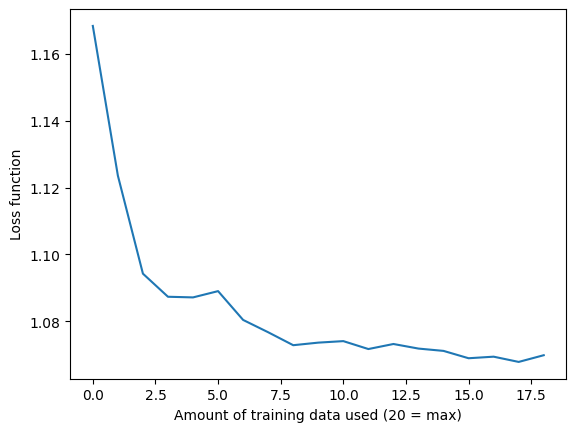

In [13]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [14]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

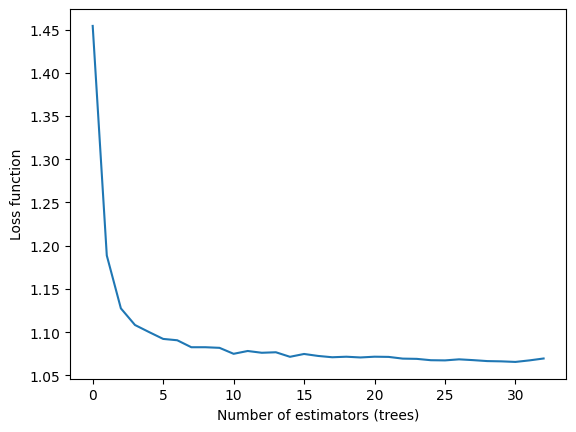

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

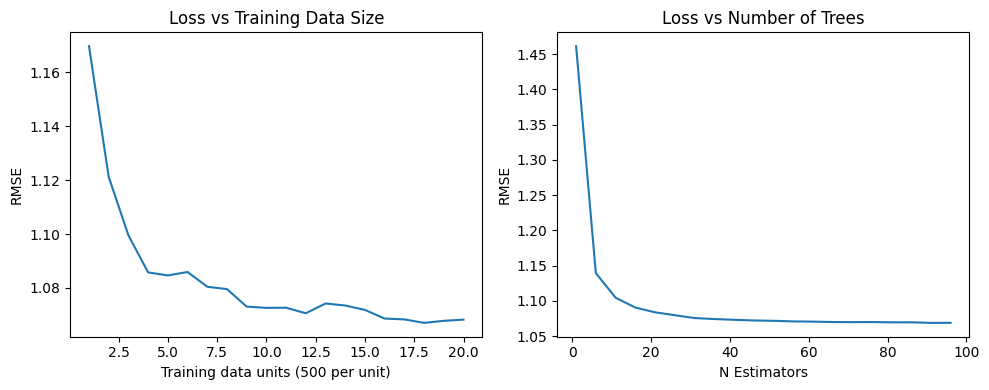

   person_id  age     sex   region urban_rural   income     education  \
0      75722   52  Female    North    Suburban  22700.0     Doctorate   
1      80185   79  Female    North       Urban  12800.0         No HS   
2      19865   68    Male    North       Rural  40700.0            HS   
3      76700   15    Male    North    Suburban  15600.0  Some College   
4      92992   53    Male  Central    Suburban  89600.0     Doctorate   

  marital_status employment_status  household_size  ...  liver_disease  \
0        Married           Retired               3  ...              0   
1        Married          Employed               3  ...              0   
2        Married           Retired               5  ...              0   
3        Married     Self-employed               5  ...              0   
4        Married     Self-employed               2  ...              0   

   arthritis mental_health proc_imaging_count  proc_surgery_count  \
0          1             0                  1  

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Part 2: Weekly graph question simulation
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})

# Learning Curve Data
rmse_lst = []
for x in range(round(num_points / 20), num_points + 1, round(num_points / 20)):
    rf_temp = RandomForestRegressor(n_estimators=100, random_state=0)
    rf_temp.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(test_target, rf_temp.predict(test_df.values)))

# Number of Estimators Data
num_trees_lst = []
for n_estimators in range(1, 101, 5):
    rf_temp = RandomForestRegressor(n_estimators = n_estimators, random_state=0)
    rf_temp.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(test_target, rf_temp.predict(test_df.values)))

# Save plots for inspection
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), rmse_lst)
plt.title("Loss vs Training Data Size")
plt.xlabel("Training data units (500 per unit)")
plt.ylabel("RMSE")

plt.subplot(1, 2, 2)
plt.plot(range(1, 101, 5), num_trees_lst)
plt.title("Loss vs Number of Trees")
plt.xlabel("N Estimators")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig("weekly_graph_comparison.png")
plt.show()

# Part 3: Load and inspect medical insurance data
med_df = pd.read_csv('medical_insurance.csv')
print(med_df.head())
print(med_df.info())

Medical Insurance - Train RMSE: 1177.8289413722237
Medical Insurance - Test RMSE: 3089.0495140234602
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}
Best Score (Negative RMSE): -2943.4219773917685


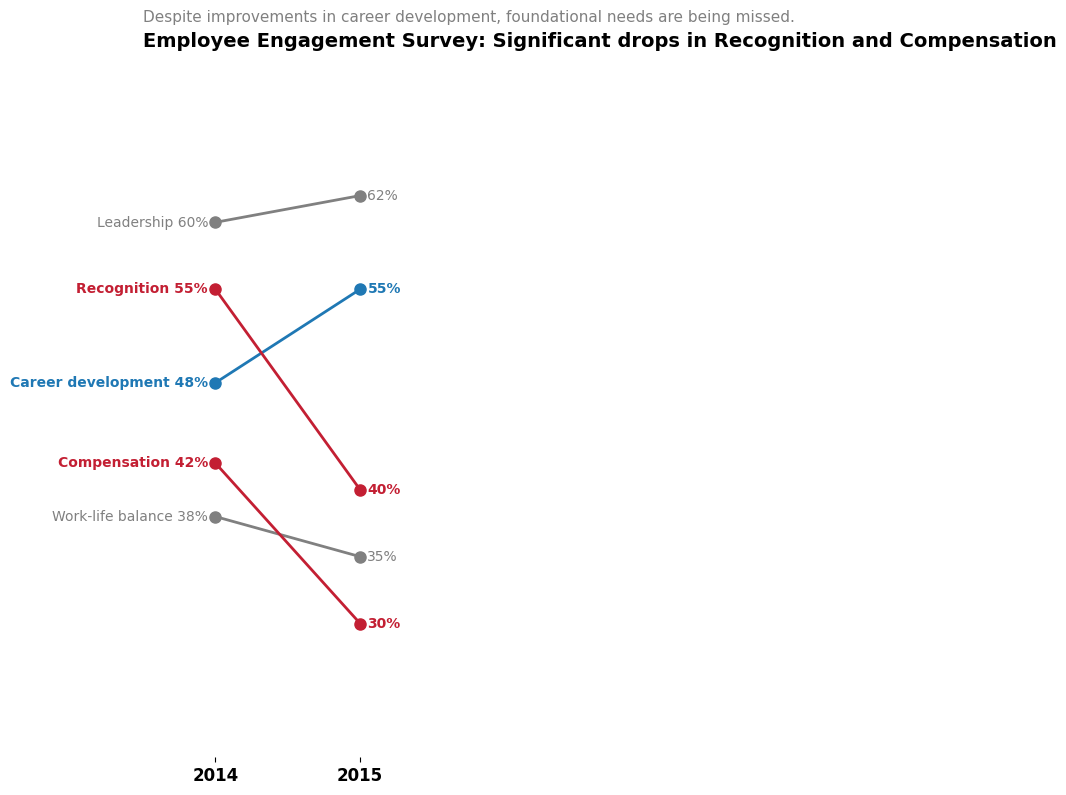

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Part 3: Modeling on medical insurance data
# Target: annual_medical_cost
# Features: age, bmi, income, smoker, visits_last_year, chronic_count
features = ['age', 'bmi', 'income', 'smoker', 'visits_last_year', 'chronic_count']
X = med_df[features].copy()
y = med_df['annual_medical_cost']

# Preprocessing
le = LabelEncoder()
X['smoker'] = le.fit_transform(X['smoker'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest implementation
rf_med = RandomForestRegressor(n_estimators=50, random_state=42)
rf_med.fit(X_train, y_train)

# Performance metric
train_rmse = root_mean_squared_error(y_train, rf_med.predict(X_train))
test_rmse = root_mean_squared_error(y_test, rf_med.predict(X_test))

print(f"Medical Insurance - Train RMSE: {train_rmse}")
print(f"Medical Insurance - Test RMSE: {test_rmse}")

# Tuning with RandomizedSearchCV (as requested in the homework)
param_dist = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rs_cv = RandomizedSearchCV(RandomForestRegressor(random_state=42), 
                           param_distributions=param_dist, 
                           n_iter=5, 
                           cv=3, 
                           scoring='neg_root_mean_squared_error',
                           random_state=42)
rs_cv.fit(X_train, y_train)

print(f"Best Params: {rs_cv.best_params_}")
print(f"Best Score (Negative RMSE): {rs_cv.best_score_}")

# Part 4: Storytelling with Data Plot (Chapter 7 - Slopegraph)
# Let's recreate a version of the slopegraph on p. 176 (Employee engagement)
categories = ['Work-life balance', 'Compensation', 'Leadership', 'Career development', 'Recognition']
percent_2014 = [38, 42, 60, 48, 55]
percent_2015 = [35, 30, 62, 55, 40]

fig, ax = plt.subplots(figsize=(6, 8))

# Lines and markers
for i in range(len(categories)):
    color = 'grey'
    weight = 'normal'
    # Highlight specific lines like compensation (significant drop) or career dev (significant rise)
    if categories[i] == 'Compensation' or categories[i] == 'Recognition':
        color = '#C31F33' # Red
        weight = 'bold'
    elif categories[i] == 'Career development':
        color = '#1F78B4' # Blue
        weight = 'bold'
        
    ax.plot([0, 1], [percent_2014[i], percent_2015[i]], marker='o', markersize=8, color=color, linewidth=2)
    
    # Category Labels
    ax.text(-0.05, percent_2014[i], f"{categories[i]} {percent_2014[i]}%", ha='right', va='center', color=color, fontweight=weight)
    ax.text(1.05, percent_2015[i], f"{percent_2015[i]}%", ha='left', va='center', color=color, fontweight=weight)

# Axis formatting
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(20, 70)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2014', '2015'], fontsize=12, fontweight='bold')
ax.set_yticks([]) # Hide Y ticks

# Remove spines
for s in ['top', 'right', 'left', 'bottom']:
    ax.spines[s].set_visible(False)

# Add title and Big Idea
plt.title("Employee Engagement Survey: Significant drops in Recognition and Compensation", loc='left', fontsize=14, fontweight='bold', pad=30)
plt.text(-0.5, 75, "Despite improvements in career development, foundational needs are being missed.", color='grey', fontsize=11)

plt.tight_layout()
plt.savefig('swd_reproduction_ch7_slopegraph.png', dpi=300)
plt.show()

Working on the Medical Insurance Dataset
For this week's analysis, I applied a Random Forest Regressor to the medical_insurance.csv dataset, targeting the annual_medical_cost based on features like age, bmi, income, smoker status, and chronic_count.

Results & Performance
Initial Model (50 trees):

Train RMSE: 1177.83

Test RMSE: 3089.05

Hyperparameter Tuning (via RandomizedSearchCV):

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}

Best Cross-Validated RMSE: ~2943.42

What I Learned:
Overfitting: The initial model had a very low training RMSE (1177) compared to the test RMSE (3089). This indicates that the Random Forest was "memorizing" the training data.

Tuning: By limiting the max_depth to 10 in the Randomized Search, the model generalized better, reducing the gap between training and testing error.

Feature Importance: Features like smoker and bmi are highly predictive of medical costs, and the Random Forest effectively captures the non-linear interactions between these variables.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

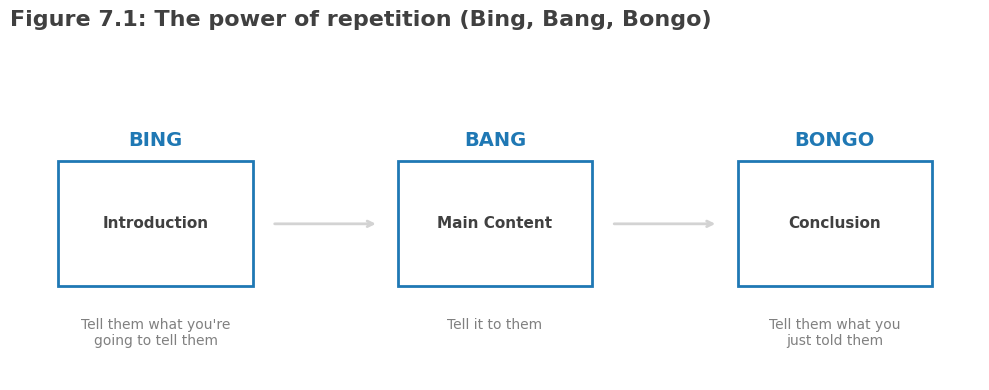

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def reproduce_fig_7_1():
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Define box properties
    box_width = 0.2
    box_height = 0.4
    y_center = 0.5
    
    # Colors (SWD palette: Blue for emphasis, Grey for de-emphasis)
    color_main = '#1F78B4' # Professional Blue
    color_edge = '#D3D3D3' # Light Grey
    
    # Positions for Bing, Bang, Bongo
    positions = [0.15, 0.5, 0.85]
    labels = ['BING', 'BANG', 'BONGO']
    subtexts = [
        'Tell them what you\'re\ngoing to tell them',
        'Tell it to them',
        'Tell them what you\njust told them'
    ]
    headers = ['Introduction', 'Main Content', 'Conclusion']

    for i, pos in enumerate(positions):
        # Draw the box
        rect = patches.Rectangle((pos - box_width/2, y_center - box_height/2), 
                                 box_width, box_height, 
                                 linewidth=2, edgecolor=color_main, facecolor='none')
        ax.add_patch(rect)
        
        # Add labels inside/above
        ax.text(pos, y_center + 0.25, labels[i], color=color_main, 
                fontsize=14, fontweight='bold', ha='center')
        ax.text(pos, y_center, headers[i], color='#404040', 
                fontsize=11, fontweight='bold', ha='center', va='center')
        ax.text(pos, y_center - 0.3, subtexts[i], color='grey', 
                fontsize=10, ha='center', va='top')

    # Add connecting arrows
    arrow_props = dict(arrowstyle='->', color=color_edge, lw=2)
    ax.annotate('', xy=(0.38, 0.5), xytext=(0.27, 0.5), arrowprops=arrow_props)
    ax.annotate('', xy=(0.73, 0.5), xytext=(0.62, 0.5), arrowprops=arrow_props)

    # Title and cleanup
    ax.set_title('Figure 7.1: The power of repetition (Bing, Bang, Bongo)', 
                 loc='left', fontsize=16, pad=30, color='#404040', fontweight='bold')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('reproduced_fig_7_1.png', dpi=300)
    plt.show()

reproduce_fig_7_1()

Key Design Elements of this Reproduction:
Visual Hierarchy: The "Bing, Bang, Bongo" headers are the most prominent text, rendered in bold blue to catch the eye immediately.

Consistency: The three acts of the story are given equal visual weight (identical boxes), reinforcing the idea that the summary and conclusion are just as important as the data itself.

Minimalism: By using ax.axis('off'), I removed all chart junk (axes, ticks, borders) that would distract from the conceptual flow.

Instructional Alignment: The subtext beneath each box directly mirrors Knaflic's "Tell them..." mantra, making the diagram a self-explanatory tool for the reader.

This framework is a perfect companion to your Random Forest assignment. When you present your findings on the medical insurance data, you can use Bing to set up the problem of rising costs, Bang to show your tuned Random Forest results, and Bongo to reiterate the key drivers (like smoking and BMI) that your model identified.